# Albumentations 변환들 확인 및 정리
이 노트북에서는 Albumentations 라이브러리에서 제공하는 다양한 이미지 변환들을 직접 이용해보고 결과를 확인합니다.

## 1. 라이브러리 임포트
Albumentations, Numpy, Matplotlib 등의 필요한 라이브러리를 임포트합니다.

In [1]:
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
import cv2

/workspaces/charuco/.venv/lib/python3.12/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 2. 샘플 이미지 로드
테스트용 샘플 이미지를 생성하여 변환에 사용할 준비를 합니다. Numpy를 사용하여 간단한 체크보드 패턴 이미지를 만듭니다.

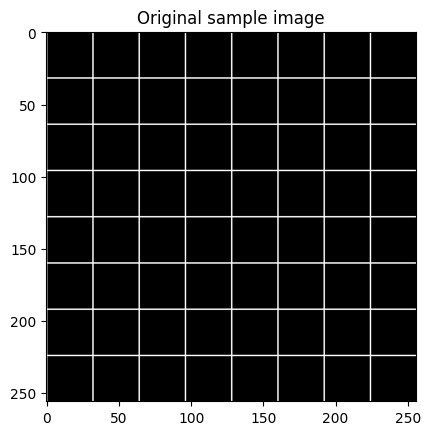

In [3]:
# 샘플 이미지 생성 (체크보드 패턴)
image = np.zeros((256, 256, 3), dtype=np.uint8)
image[::32, :] = 255 # 수직라인
image[:, ::32] = 255 # 수평라인

plt.imshow(image)
plt.title("Original sample image")
plt.show()

## 3. 기본 변환 적용
Albumentations 의 기본 변환(예: Rotate, Flip 등)을 이미지에 적용하고 결과를 확인합니다.

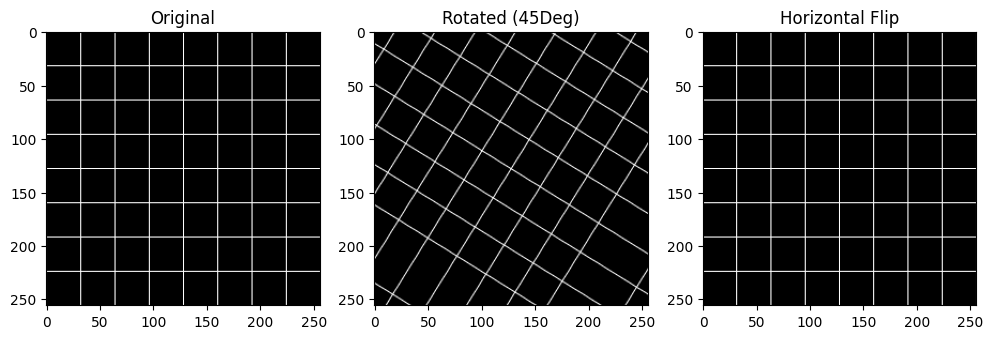

In [4]:
# Rotate 변환 적용
transform_rotate = A.Rotate(limit=45, p=1.0) # 45도까지 회전
rotated_image = transform_rotate(image=image)['image']

# Flip 변환 적용
transform_flip = A.HorizontalFlip(p=1.0)
flipped_image = transform_flip(image=image)['image']

# 결과 표시
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[1].imshow(rotated_image)
axes[1].set_title("Rotated (45Deg)")
axes[2].imshow(flipped_image)
axes[2].set_title("Horizontal Flip")
plt.show()

## 4. 여러 변환 조합
여러 변환을 Compose를 사용하여 조합하고, 파이프라인으로 적용합니다.

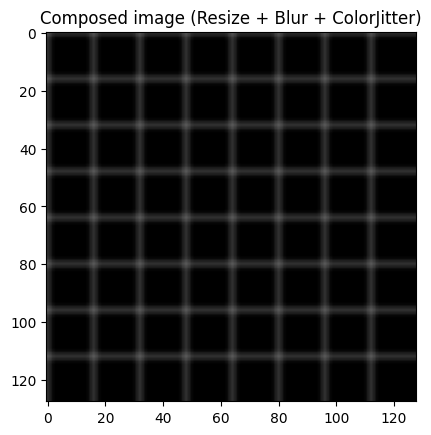

In [5]:
# 여러 변환 조합 (Compose 사용)
transform_compose = A.Compose([
    A.Resize(height=128, width=128),
    A.GaussianBlur(blur_limit=(3, 7), p=1.0),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=1.0)
])

composed_image = transform_compose(image=image)['image']

plt.imshow(composed_image)
plt.title("Composed image (Resize + Blur + ColorJitter)")
plt.show()

## 5. 결과 시각화
원본 이미지와 변환된 이미지를 나란히 시각화하여 차이를 비교합니다.

/tmp/ipykernel_18861/1206178064.py:32: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18861/1206178064.py:32: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/charuco/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspaces/charuco/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


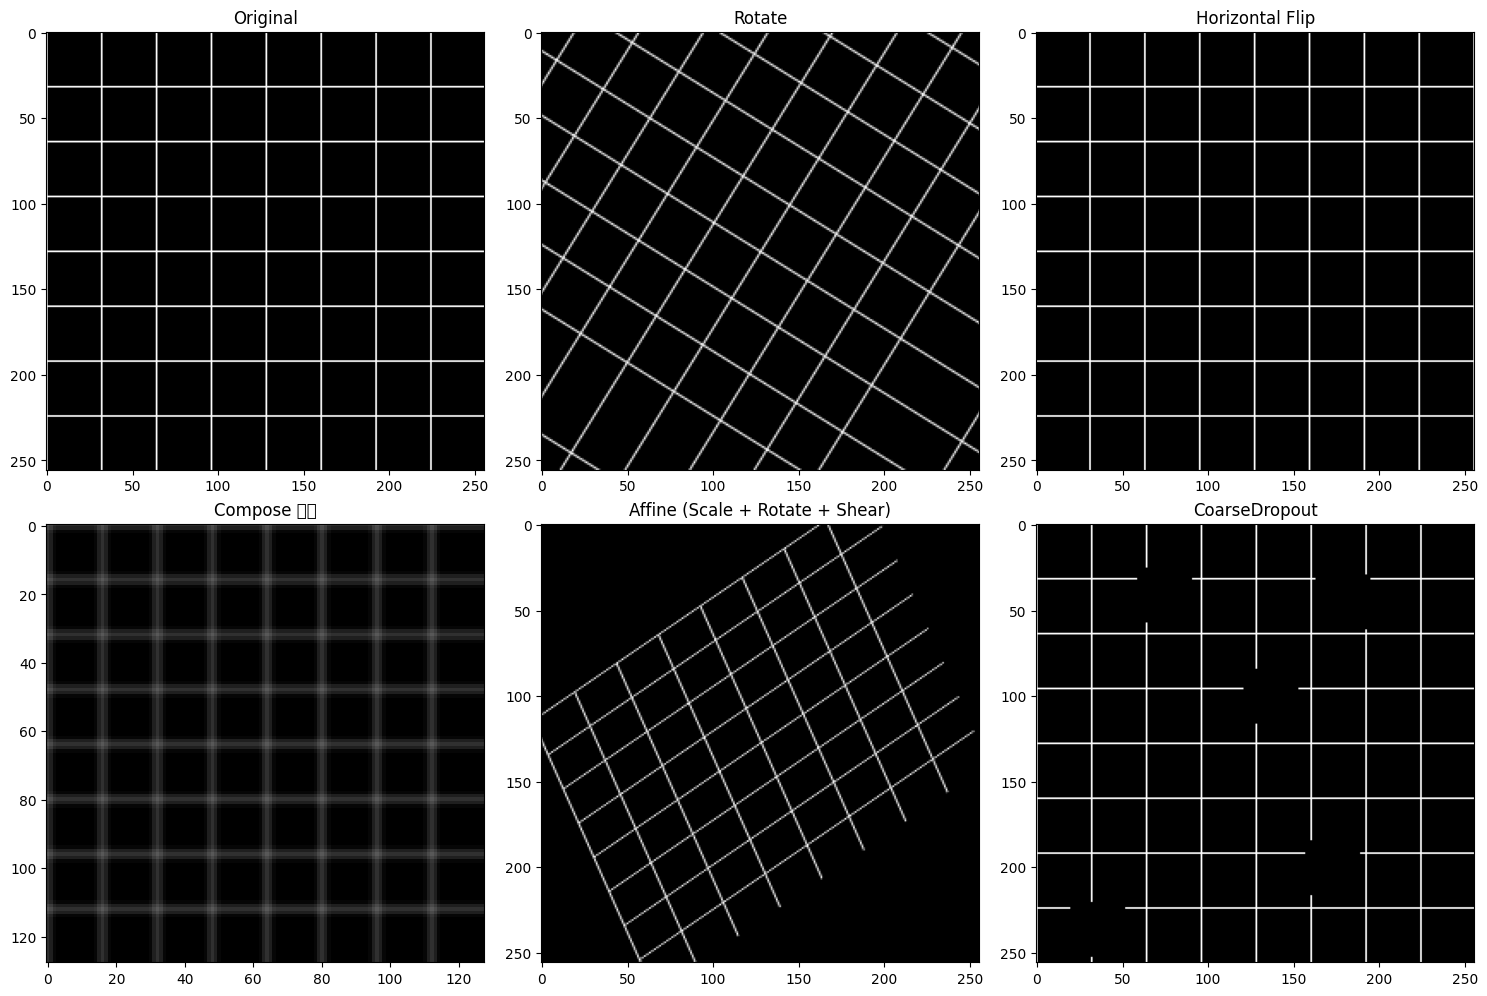

In [7]:
# 종합 시각화: 원본과 여러 변환 결과 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 원본 이미지
axes[0, 0].imshow(image)
axes[0, 0].set_title("Original")

# Rotate 변환
axes[0, 1].imshow(rotated_image)
axes[0, 1].set_title("Rotate")

# Flip
axes[0, 2].imshow(flipped_image)
axes[0, 2].set_title("Horizontal Flip")

# Compose (Resize + Blur + ColorJitter)
axes[1, 0].imshow(composed_image)
axes[1, 0].set_title("Compose 변환")

# 추가 변환 예시: Affine
transform_affine = A.Affine(scale=0.8, rotate=30, shear=10, p=1.0)
affine_image = transform_affine(image=image)['image']
axes[1, 1].imshow(affine_image)
axes[1, 1].set_title("Affine (Scale + Rotate + Shear)")

# CoarseDropout
transform_dropout = A.CoarseDropout(max_holes=5, max_height=32, max_width=32, p=0.1)
dropout_image = transform_dropout(image=image)['image']
axes[1, 2].imshow(dropout_image)
axes[1, 2].set_title("CoarseDropout")

plt.tight_layout()
plt.show()